In [1]:
import pandas as pd, numpy as np

In [2]:
df = pd.read_csv("../datasets/credit_risk_dataset.csv")

### EDA

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [5]:
df.describe(percentiles=[0.25, 0.5, 0.75, 0.99])

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
99%,50.000000,2.252000e+05,18.000000,29800.000000,18.620000,1.000000,0.500000,17.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


- Age and emp length has anomalies (max age = 144, max emp length = 123) not possible

In [6]:
numeric_columns = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']


df[numeric_columns].skew()



person_age                     2.581393
person_income                 32.865349
person_emp_length              2.614455
loan_amnt                      1.192477
loan_int_rate                  0.208550
loan_status                    1.364888
loan_percent_income            1.064669
cb_person_cred_hist_length     1.661790
dtype: float64

- Apart from loan_int_rate, every feature is right skewed, especially person_income.

In [7]:
# Calculate correlation of all numeric features specifically with the target
correlations = df.corr(numeric_only=True)['loan_status'].sort_values(ascending=False)
print("Correlation with target variable:\n", correlations)


Correlation with target variable:
 loan_status                   1.000000
loan_percent_income           0.379366
loan_int_rate                 0.335133
loan_amnt                     0.105376
cb_person_cred_hist_length   -0.015529
person_age                   -0.021629
person_emp_length            -0.082489
person_income                -0.144449
Name: loan_status, dtype: float64


- All features have little to no correlation with loan_status

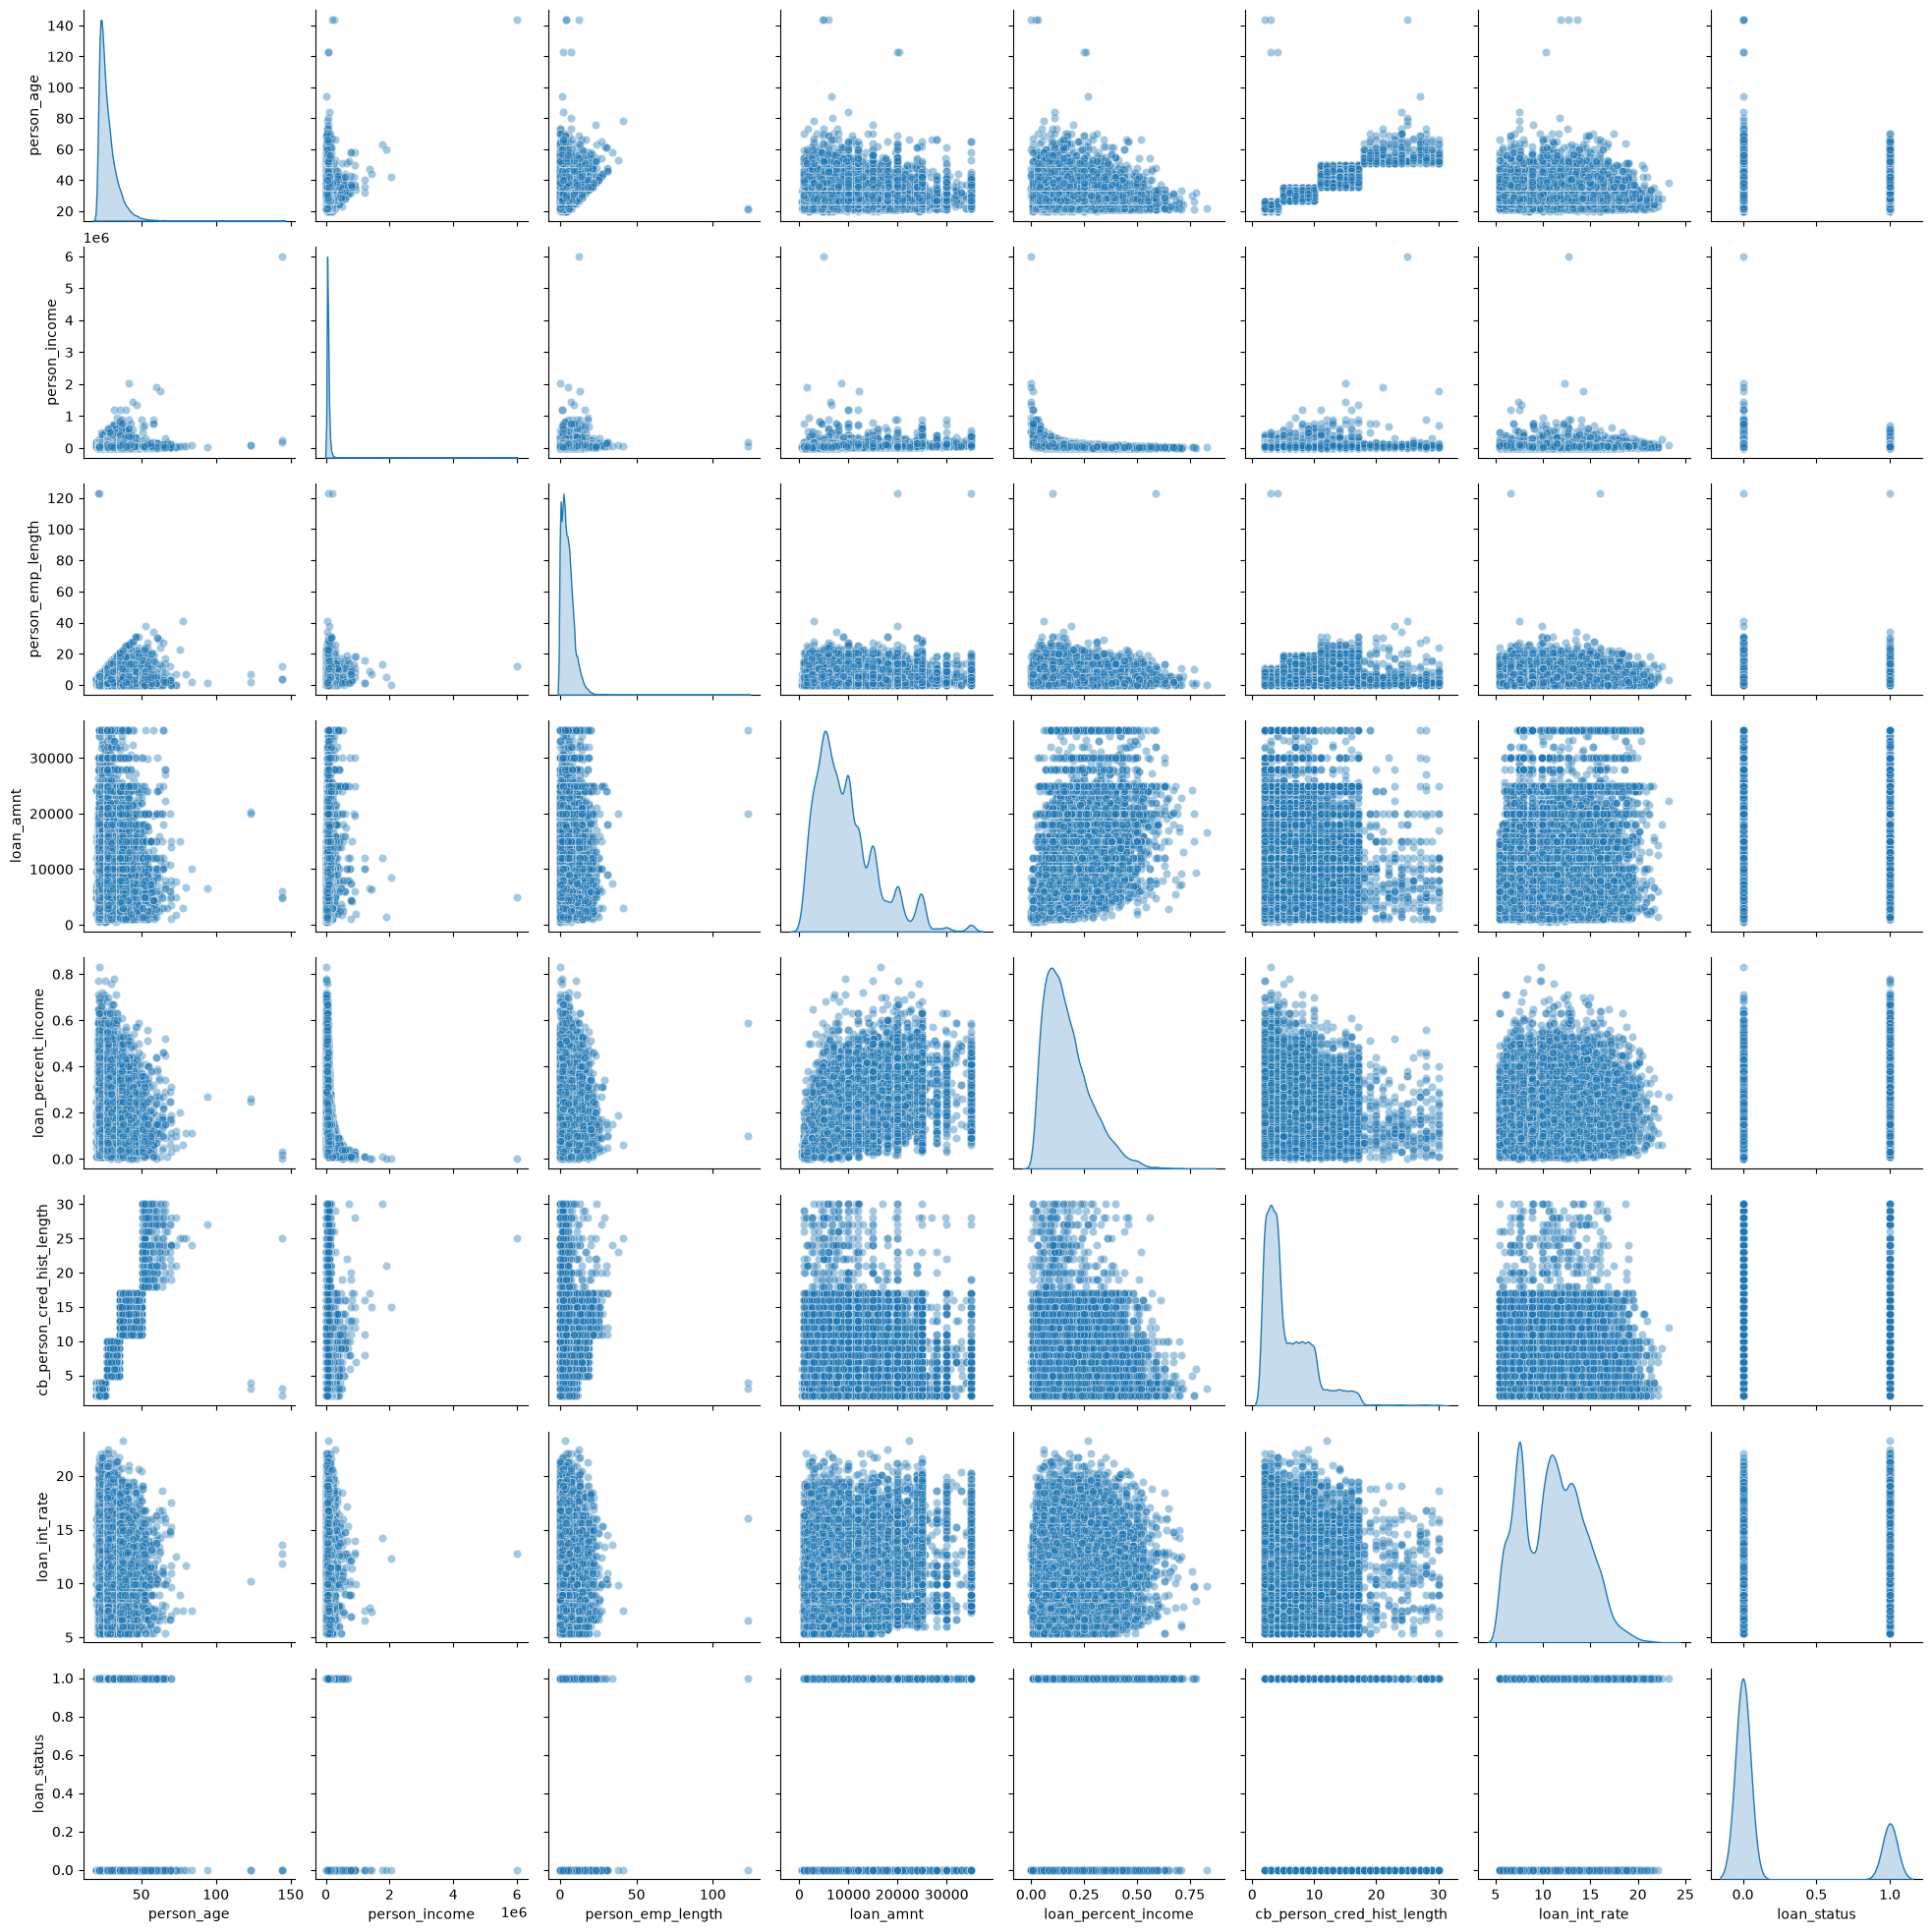

In [8]:
import seaborn as sns, matplotlib.pyplot as plt

# Select target and a subset of features
subset_cols = ['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length', 'loan_int_rate', 'loan_status']

# Pairplot targeting relationships
sns.pairplot(df[subset_cols], diag_kind='kde', plot_kws={'alpha': 0.4})
plt.show()


In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Create a numeric design matrix for VIF by encoding categorical columns
df_numeric = pd.get_dummies(df, drop_first=True).astype(float)
df_numeric.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22.0,59000.0,123.0,35000.0,16.02,1.0,0.59,3.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,21.0,9600.0,5.0,1000.0,11.14,0.0,0.10,2.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,25.0,9600.0,1.0,5500.0,12.87,1.0,0.57,3.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,23.0,65500.0,4.0,35000.0,15.23,1.0,0.53,2.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,24.0,54400.0,8.0,35000.0,14.27,1.0,0.55,4.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [10]:
null_columns = df_numeric.columns[df_numeric.isna().any()].tolist()
null_columns

['person_emp_length', 'loan_int_rate']

In [11]:
df_numeric_imputed = df_numeric.fillna(df_numeric.median())
df_numeric_imputed[null_columns].isna().sum()

person_emp_length    0
loan_int_rate        0
dtype: int64

In [12]:
# Add an intercept column (constant)
df_numeric_with_constant = add_constant(df_numeric_imputed)

# Compute VIF for each feature column (excluding the intercept)
vif_df = pd.DataFrame({
    "Feature": df_numeric_with_constant.columns[1:],
    "VIF": [
        variance_inflation_factor(df_numeric_with_constant.values, i)
        for i in range(1, df_numeric_with_constant.shape[1])
    ]
})

print(vif_df)

                        Feature       VIF
0                    person_age  3.928692
1                 person_income  1.511638
2             person_emp_length  1.103041
3                     loan_amnt  2.280119
4                 loan_int_rate  5.587729
5                   loan_status  1.544277
6           loan_percent_income  2.477882
7    cb_person_cred_hist_length  3.838324
8   person_home_ownership_OTHER  1.007402
9     person_home_ownership_OWN  1.162848
10   person_home_ownership_RENT  1.303058
11        loan_intent_EDUCATION  1.823946
12  loan_intent_HOMEIMPROVEMENT  1.523200
13          loan_intent_MEDICAL  1.773021
14         loan_intent_PERSONAL  1.727580
15          loan_intent_VENTURE  1.777203
16                 loan_grade_B  2.768763
17                 loan_grade_C  4.640097
18                 loan_grade_D  4.759259
19                 loan_grade_E  2.508487
20                 loan_grade_F  1.493622
21                 loan_grade_G  1.186399
22  cb_person_default_on_file_Y  1

- loan_int_rate has high multicollinearity

### Data Preprocessing

In [13]:
from sklearn.model_selection import train_test_split

target = 'loan_status'
features = [col for col in df.columns if col != target]

X = df[features]
y = df[target]

# 1. First split: Separate out the test set (10% of total data)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42
)

# 2. Second split: Divide the remaining data into train and validation sets
# 0.11 calculation: 0.1 / (1.0 - 0.1) = 0.1 / 0.9 ≈ 0.1111
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1111, random_state=42
)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")


Train size: 26064 | Val size: 3258 | Test size: 3259


In [14]:
X_train.describe(percentiles=[0.25, 0.5, 0.75, 0.99])

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,26064.000000,2.606400e+04,25354.000000,26064.000000,23584.000000,26064.000000,26064.000000
mean,27.745204,6.609249e+04,4.776169,9601.198972,11.002548,0.170416,5.807551
std,6.342907,6.446525e+04,4.094729,6326.634864,3.240004,0.106835,4.050125
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000
25%,23.000000,3.868275e+04,2.000000,5000.000000,7.900000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.150000,4.000000
75%,30.000000,7.905000e+04,7.000000,12250.000000,13.470000,0.230000,8.000000
99%,50.000000,2.250000e+05,17.000000,29800.000000,18.530000,0.500000,17.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,22.480000,0.830000,30.000000


In [15]:
outlier_filter = (
    (X_train['person_age'] <= 100) & 
    (X_train['person_emp_length'] <= 40) & 
    (X_train['person_age'] - X_train['person_emp_length'] >= 14) & 
    (X_train['person_age'] - X_train['cb_person_cred_hist_length'] >= 14)
)

X_train_cleaned = X_train[outlier_filter]
X_train_cleaned.describe(percentiles=[0.25, 0.5, 0.75, 0.99])

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,25349.000000,2.534900e+04,25349.000000,25349.000000,22922.000000,25349.000000,25349.000000
mean,27.740739,6.644809e+04,4.769932,9673.485147,11.029185,0.169873,5.810643
std,6.233092,5.316586e+04,4.020512,6340.307496,3.228271,0.106252,4.052603
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000
25%,23.000000,3.950000e+04,2.000000,5000.000000,7.900000,0.090000,3.000000
50%,26.000000,5.555000e+04,4.000000,8000.000000,10.990000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.230000,8.000000
99%,50.000000,2.250000e+05,17.000000,30000.000000,18.620000,0.490000,17.000000
max,94.000000,2.039784e+06,38.000000,35000.000000,22.480000,0.830000,30.000000


In [16]:
# Aligning the training target labels with the filtered features
y_train_cleaned = y_train[outlier_filter]

In [17]:
# 1. Calculate the median interest rate for each loan grade using ONLY the training data
# This creates a Series where the index is the loan_grade and the value is the median rate
grade_medians = X_train_cleaned.groupby('loan_grade')['loan_int_rate'].median()

# Calculate median person emp length
emp_length_median = X_train_cleaned['person_emp_length'].median()

# 2. Impute missing values in the Training set natively using its own grouped medians
X_train_cleaned['loan_int_rate'] = X_train_cleaned['loan_int_rate'].fillna(
    X_train_cleaned['loan_grade'].map(grade_medians)
)

# 3. Impute missing values in the Validation set using the TRAINING medians mapping
X_val['loan_int_rate'] = X_val['loan_int_rate'].fillna(
    X_val['loan_grade'].map(grade_medians)
)

X_val['person_emp_length'] = X_val['person_emp_length'].fillna(emp_length_median)

# 4. Impute missing values in the Test set using the TRAINING medians mapping
X_test['loan_int_rate'] = X_test['loan_int_rate'].fillna(
    X_test['loan_grade'].map(grade_medians)
)

X_test['person_emp_length'] = X_test['person_emp_length'].fillna(emp_length_median)

In [18]:
X_val.isna().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [19]:
X_test.isna().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [20]:
from sklearn.preprocessing import OneHotEncoder

# 1. Initialize OneHotEncoder
# sparse_output=False returns a dense array instead of a sparse matrix
# handle_unknown='ignore' prevents crashes if new categories appear during testing
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# 2. Configure scikit-learn to output data as a Pandas DataFrame
encoder.set_output(transform='pandas')

# 3. Fit and transform the specific categorical column(s)
# Note: Input must be a 2D array/DataFrame, so use double brackets [['Column']]
categorical_columns = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
encoded_features = encoder.fit_transform(X_train_cleaned[categorical_columns])

# 4. Combine the new binary features back with the rest of your original data
X_train_encoded = pd.concat([X_train_cleaned.copy().drop(columns=categorical_columns), encoded_features], axis=1)

X_train_encoded.head()


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
12106,25,80000,9.0,4000,19.03,0.05,3,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
22450,31,52249,7.0,7000,7.49,0.13,7,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
28294,27,50000,0.0,8000,7.90,0.16,8,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16960,22,69000,6.0,10000,15.62,0.14,3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
16507,26,42000,0.0,4500,11.48,0.11,3,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
columns_to_transform = ['person_income']
X_train_encoded[columns_to_transform] = np.log1p(X_train_encoded[columns_to_transform])
X_train_encoded.skew()


person_age                      1.965866
person_income                   0.183038
person_emp_length               1.229347
loan_amnt                       1.171017
loan_int_rate                   0.204753
loan_percent_income             1.054313
cb_person_cred_hist_length      1.671509
person_home_ownership_OTHER    17.286194
person_home_ownership_OWN       3.201828
person_home_ownership_RENT     -0.021858
loan_intent_EDUCATION           1.502495
loan_intent_HOMEIMPROVEMENT     2.490073
loan_intent_MEDICAL             1.630865
loan_intent_PERSONAL            1.760243
loan_intent_VENTURE             1.702915
loan_grade_B                    0.758943
loan_grade_C                    1.509925
loan_grade_D                    2.462089
loan_grade_E                    5.492780
loan_grade_F                   11.741007
loan_grade_G                   22.450871
cb_person_default_on_file_Y     1.687629
dtype: float64

In [22]:
def preprocess_split(X_df, encoder, categorical_cols, income_col=['person_income']):
    """
    Transforms a data split (validation or test) using the fitted training encoder 
    and applies a log transformation to the income column.
    """
    # 1. Transform the categorical features using the ALREADY FITTED encoder
    encoded_array = encoder.transform(X_df[categorical_cols])
    
    # 2. Combine the non-categorical columns with the newly encoded columns
    X_encoded = pd.concat(
        [
            X_df.drop(columns=categorical_cols),
            encoded_array
        ],
        axis=1
    )
    
    # 3. Apply the natural log log1p transformation to the income column
    X_encoded[income_col] = np.log1p(X_encoded[income_col])
    
    return X_encoded

# ---- Apply the function to your Validation and Test sets ----

# Transform the Validation set
X_val_encoded = preprocess_split(X_val, encoder, categorical_columns)

# Transform the Test set
X_test_encoded = preprocess_split(X_test, encoder, categorical_columns)

print(f"Cleaned Train shape: {X_train_encoded.shape}")
print(f"Transformed Val shape:  {X_val_encoded.shape}")
print(f"Transformed Test shape: {X_test_encoded.shape}")

print("Val Income Skewness:", X_val_encoded['person_income'].skew())
print("Test Income Skewness:", X_test_encoded['person_income'].skew())

Cleaned Train shape: (25349, 22)
Transformed Val shape:  (3258, 22)
Transformed Test shape: (3259, 22)
Val Income Skewness: 0.18508326475329612
Test Income Skewness: 0.029942305781374044


In [23]:
X_train_encoded.describe(percentiles=[0.25, 0.5, 0.75, 0.99])

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
count,25349.000000,25349.000000,25349.000000,25349.000000,25349.000000,25349.000000,25349.000000,25349.000000,25349.000000,25349.000000,...,25349.000000,25349.000000,25349.000000,25349.000000,25349.000000,25349.000000,25349.000000,25349.000000,25349.000000,25349.000000
mean,27.740739,10.936588,4.769932,9673.485147,11.031931,0.169873,5.810643,0.003314,0.075940,0.505464,...,0.184031,0.169671,0.175865,0.322616,0.198746,0.111918,0.030179,0.007101,0.001972,0.177561
std,6.233092,0.558092,4.020512,6340.307496,3.197903,0.106252,4.052603,0.057471,0.264907,0.499980,...,0.387517,0.375351,0.380713,0.467487,0.399064,0.315271,0.171082,0.083969,0.044369,0.382151
min,20.000000,8.294300,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,10.584081,2.000000,5000.000000,7.900000,0.090000,3.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,26.000000,10.925057,4.000000,8000.000000,10.990000,0.150000,4.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,30.000000,11.289794,7.000000,12500.000000,13.480000,0.230000,8.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
99%,50.000000,12.323860,17.000000,30000.000000,18.532600,0.490000,17.000000,0.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
max,94.000000,14.528355,38.000000,35000.000000,22.480000,0.830000,30.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [24]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

columns_to_scale = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

X_train_encoded[columns_to_scale] = scaler.fit_transform(X_train_encoded[columns_to_scale])

In [25]:
X_train_encoded.describe(percentiles=[0.25, 0.5, 0.75, 0.99])

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
count,2.534900e+04,2.534900e+04,2.534900e+04,2.534900e+04,2.534900e+04,2.534900e+04,2.534900e+04,25349.000000,25349.000000,25349.000000,...,25349.000000,25349.000000,25349.000000,25349.000000,25349.000000,25349.000000,25349.000000,25349.000000,25349.000000,25349.000000
mean,1.901863e-16,-5.359413e-16,-2.242432e-18,7.960635e-17,-7.164572e-16,-1.956522e-16,-1.079171e-16,0.003314,0.075940,0.505464,...,0.184031,0.169671,0.175865,0.322616,0.198746,0.111918,0.030179,0.007101,0.001972,0.177561
std,1.000020e+00,1.000020e+00,1.000020e+00,1.000020e+00,1.000020e+00,1.000020e+00,1.000020e+00,0.057471,0.264907,0.499980,...,0.387517,0.375351,0.380713,0.467487,0.399064,0.315271,0.171082,0.083969,0.044369,0.382151
min,-1.241902e+00,-4.734597e+00,-1.186422e+00,-1.446880e+00,-1.754913e+00,-1.598804e+00,-9.403139e-01,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-7.605909e-01,-6.316411e-01,-6.889635e-01,-7.371216e-01,-9.793895e-01,-7.517434e-01,-6.935540e-01,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-2.792793e-01,-2.066252e-02,-1.915047e-01,-2.639491e-01,-1.311230e-02,-1.870364e-01,-4.467942e-01,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.624694e-01,6.328943e-01,5.546836e-01,4.458097e-01,7.655382e-01,5.659063e-01,5.402454e-01,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
99%,3.571213e+00,2.485790e+00,3.041978e+00,3.205983e+00,2.345542e+00,3.012970e+00,2.761084e+00,0.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
max,1.063045e+01,6.435924e+00,8.265296e+00,3.994603e+00,3.579938e+00,6.212977e+00,5.968963e+00,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [26]:
X_val_encoded[columns_to_scale] = scaler.transform(X_val_encoded[columns_to_scale])
X_test_encoded[columns_to_scale] = scaler.transform(X_test_encoded[columns_to_scale])

In [27]:
y_train_cleaned.value_counts()

loan_status
0    19906
1     5443
Name: count, dtype: int64

### Model Training

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TunedThresholdClassifierCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 2. Initialize base logistic regression
model = LogisticRegression(class_weight='balanced')

# Wrap the model to optimize for a specific metric (e.g., F1-score)
# It automatically runs cross-validation to search for the best threshold
tuned_model = TunedThresholdClassifierCV(estimator=model, scoring='f1', cv=5)
tuned_model.fit(X_train_encoded, y_train_cleaned)

# 4. Extract the optimal threshold and predict
print(f"Optimal Threshold: {tuned_model.best_threshold_:.4f}")

y_pred = tuned_model.predict(X_val_encoded)
print(classification_report(y_val, y_pred))

Optimal Threshold: 0.6462
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      2570
           1       0.65      0.70      0.67       688

    accuracy                           0.86      3258
   macro avg       0.78      0.80      0.79      3258
weighted avg       0.86      0.86      0.86      3258



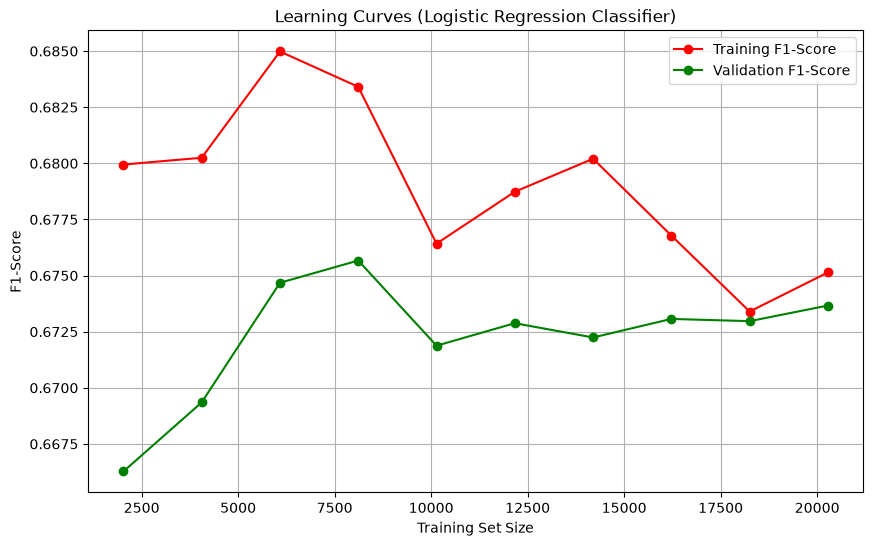

In [29]:
from sklearn.model_selection import learning_curve

# 1. Define the training sizes to evaluate (from 10% to 100% of the training data)
train_sizes = np.linspace(0.1, 1.0, 10)

# 2. Compute the learning curves
# We use the base 'model' or 'tuned_model' here. Note:cv=5 matches your previous setup.
sizes, train_scores, val_scores = learning_curve(
    estimator=tuned_model,
    X=X_train_encoded,
    y=y_train_cleaned,
    train_sizes=train_sizes,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# 3. Calculate the mean scores across the 5 cross-validation folds
train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

# 4. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(sizes, train_scores_mean, 'o-', color="r", label="Training F1-Score")
plt.plot(sizes, val_scores_mean, 'o-', color="g", label="Validation F1-Score")

plt.title("Learning Curves (Logistic Regression Classifier)")
plt.xlabel("Training Set Size")
plt.ylabel("F1-Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

- Learning curve converges at around f1 score of 0.675 --> sign of underfitting

In [30]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Construct a pipeline 
# It builds polynomial combinations, and fits the classifier
poly_logistic_model = Pipeline([
    ('poly_features', PolynomialFeatures(degree=3, include_bias=False)),
    ('logistic_clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

# Train the model
poly_logistic_model.fit(X_train_encoded, y_train_cleaned)

# Predict on validation set
y_pred = poly_logistic_model.predict(X_val_encoded)

# Evaluate accuracy metrics
print("Classification Report:")
print(classification_report(y_val, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      2570
           1       0.68      0.80      0.73       688

    accuracy                           0.88      3258
   macro avg       0.81      0.85      0.83      3258
weighted avg       0.89      0.88      0.88      3258



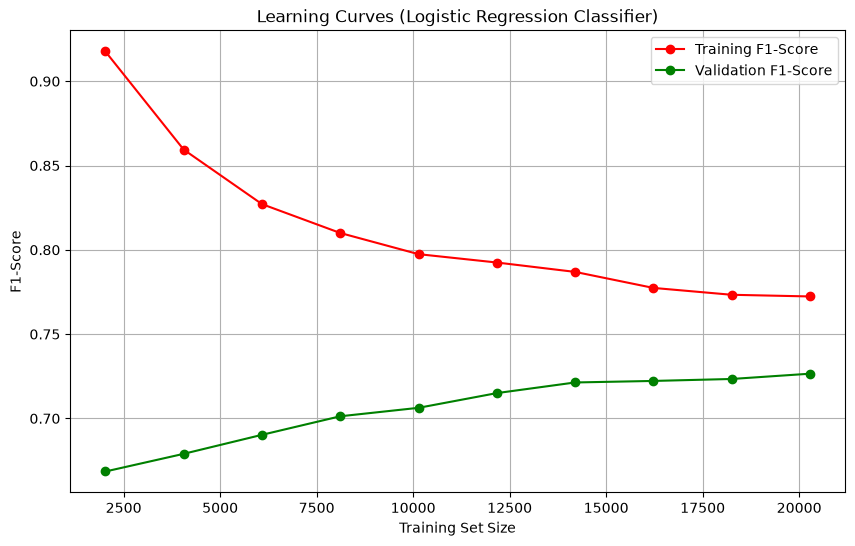

In [45]:
# 1. Define the training sizes to evaluate (from 10% to 100% of the training data)
train_sizes = np.linspace(0.1, 1.0, 10)

# 2. Compute the learning curves
# We use the base 'model' or 'tuned_model' here. Note:cv=5 matches your previous setup.
sizes, train_scores, val_scores = learning_curve(
    estimator=poly_logistic_model,
    X=X_train_encoded,
    y=y_train_cleaned,
    train_sizes=train_sizes,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# 3. Calculate the mean scores across the 5 cross-validation folds
train_scores_mean = np.mean(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)

# 4. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(sizes, train_scores_mean, 'o-', color="r", label="Training F1-Score")
plt.plot(sizes, val_scores_mean, 'o-', color="g", label="Validation F1-Score")

plt.title("Learning Curves (Logistic Regression Classifier)")
plt.xlabel("Training Set Size")
plt.ylabel("F1-Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

- Overfitting

In [32]:
from sklearn.model_selection import GridSearchCV

# Build a pipeline: Polynomial Transform -> Logistic Regression
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('log_reg', LogisticRegression(solver='liblinear', class_weight='balanced', max_iter=1000))
])

# Define the hyperparameter grid
# Use the prefix 'stepname__' to target parameters within the pipeline
param_grid = {
    'poly__degree': [1, 2, 3],             # Tune the polynomial complexity
    'log_reg__C': [0.001, 0.01, 0.1, 1, 10, 100], # Tune inverse regularization strength
    'log_reg__penalty': ['l1', 'l2']              # Tune regularization type
}

# Optimize using F1-score
# Use 'f1' for binary, or 'f1_macro' / 'f1_weighted' for multi-class/imbalanced data
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

# Fit the grid search to find the optimal parameters
grid_search.fit(X_train_encoded, y_train_cleaned)

# Results
best_model = grid_search.best_estimator_
print(f"Best parameters based on F1: {grid_search.best_params_}")
print(f"Best CV F1-score: {grid_search.best_score_:.4f}\n")


# Evaluate performance on validation data
y_pred = best_model.predict(X_val_encoded)
print("--- Final Test Performance Evaluation ---")
print(classification_report(y_val, y_pred))


Fitting 5 folds for each of 36 candidates, totalling 180 fits


d:\Study\Prep\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Best parameters based on F1: {'log_reg__C': 1, 'log_reg__penalty': 'l2', 'poly__degree': 3}
Best CV F1-score: 0.7265

--- Final Test Performance Evaluation ---
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      2570
           1       0.68      0.80      0.73       688

    accuracy                           0.88      3258
   macro avg       0.81      0.85      0.83      3258
weighted avg       0.89      0.88      0.88      3258



In [33]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_val, y_pred)

array([[2316,  254],
       [ 141,  547]])

In [34]:
# Evaluate performance on test data
y_test_pred = best_model.predict(X_test_encoded)
print("--- Final Test Performance Evaluation ---")
print(classification_report(y_test, y_test_pred))

--- Final Test Performance Evaluation ---
              precision    recall  f1-score   support

           0       0.93      0.90      0.92      2500
           1       0.71      0.79      0.75       759

    accuracy                           0.88      3259
   macro avg       0.82      0.84      0.83      3259
weighted avg       0.88      0.88      0.88      3259



In [37]:
# 1. Reach inside the pipeline and extract the individual steps
poly_step = best_model.named_steps['poly']
log_reg_step = best_model.named_steps['log_reg']

# 2. Retrieve the explicit names of all 2,300+ generated polynomial features
# Passing X_train_encoded.columns ensures the names match your actual feature labels
feature_names = poly_step.get_feature_names_out(input_features=X_train_encoded.columns)

# 3. Pull the calculated weights/coefficients from the logistic regression step
coefficients = log_reg_step.coef_[0]

# 3a. Ensure pandas prints full feature names without truncation
pd.set_option('display.max_colwidth', None)

# 4. Combine them into a structured DataFrame
importance_df = pd.DataFrame({
    'Feature_Interaction': feature_names,
    'Coefficient': coefficients,
    'Absolute_Magnitude': np.abs(coefficients)
})

# 5. Sort by absolute magnitude to find the most influential drivers
importance_df = importance_df.sort_values(by='Absolute_Magnitude', ascending=False).reset_index(drop=True)

# ---- Display the top risk drivers ----
print("Top 10 Features Driving DEFAULT Risk (Positive Coefficients):")
print(importance_df[importance_df['Coefficient'] > 0].head(10)[['Feature_Interaction', 'Coefficient']].to_string(index=False))

print("\nTop 10 Features Driving APPROVAL (Negative Coefficients):")
print(importance_df[importance_df['Coefficient'] < 0].head(10)[['Feature_Interaction', 'Coefficient']].to_string(index=False))

Top 10 Features Driving DEFAULT Risk (Positive Coefficients):
                                         Feature_Interaction  Coefficient
                               loan_amnt loan_intent_MEDICAL     2.547456
                             loan_amnt loan_intent_MEDICAL^2     2.547456
                                                   loan_amnt     2.535938
        person_income person_home_ownership_OWN loan_grade_E     1.552506
loan_percent_income loan_intent_HOMEIMPROVEMENT loan_grade_D     1.466539
            loan_percent_income^2 person_home_ownership_RENT     1.406900
        loan_int_rate person_home_ownership_OWN loan_grade_E     1.377754
                                               loan_int_rate     1.349482
  loan_percent_income person_home_ownership_OWN loan_grade_F     1.341501
             person_income loan_intent_PERSONAL loan_grade_C     1.308881

Top 10 Features Driving APPROVAL (Negative Coefficients):
                                        Feature_Interaction  Coef

### Threshold Calibration

In [38]:
# Extract the raw probability of default for the validation set
y_val_probs = best_model.predict_proba(X_val_encoded)[:, 1]
y_val_probs

array([0.08178952, 0.23274507, 0.43291767, ..., 0.0574469 , 0.19731443,
       0.24549463], shape=(3258,))

In [41]:
y_val

19921    0
8252     0
2910     0
16399    1
6768     0
        ..
7053     0
15591    0
31016    0
31040    0
7544     0
Name: loan_status, Length: 3258, dtype: int64

In [50]:
import math

FP_COST = 1500
FN_COST = 10000

best_threshold = None
min_cost = math.inf
best_cm = None

# Evaluate all unique predicted probabilities
thresholds = sorted(set(y_val_probs))

for threshold in thresholds:
    y_pred = [1 if prob >= threshold else 0 for prob in y_val_probs]

    # Compute confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    # Compute total misclassification cost
    cost = fp * FP_COST + fn * FN_COST

    if cost < min_cost:
        min_cost = cost
        best_threshold = threshold
        best_cm = (tn, fp, fn, tp)

tn, fp, fn, tp = best_cm

print(f"Optimal Threshold : {best_threshold:.4f}")
print(f"Minimum Cost      : {min_cost:.0f}\n")

print("\nConfusion Matrix (Table)")
print(f"[[{tn:5d} {fp:5d}]")
print(f" [{fn:5d} {tp:5d}]]")

Optimal Threshold : 0.4175
Minimum Cost      : 1710000


Confusion Matrix (Table)
[[ 2210   360]
 [  117   571]]


In [51]:
# 1. Extract the raw default probabilities for the Test Set
y_test_probs = best_model.predict_proba(X_test_encoded)[:, 1]

# 2. Apply your cost-calibrated threshold (0.4175)
y_test_pred_calibrated = (y_test_probs >= 0.4175).astype(int)

# 3. Apply the original standard threshold (0.5000) for comparison
y_test_pred_standard = (y_test_probs >= 0.5000).astype(int)

# 4. Compute confusion matrices for both settings
tn_std, fp_std, fn_std, tp_std = confusion_matrix(y_test, y_test_pred_standard).ravel()
tn_cal, fp_cal, fn_cal, tp_cal = confusion_matrix(y_test, y_test_pred_calibrated).ravel()

# 5. Calculate total costs ($1,500 per FP, $10,000 per FN)
cost_standard = (fp_std * FP_COST) + (fn_std * FN_COST)
cost_calibrated = (fp_cal * FP_COST) + (fn_cal * FN_COST)
net_savings = cost_standard - cost_calibrated

# 6. Display the comparative business metrics
print("--- Final Production Test Set Financial Audit ---")
print(f"Standard Threshold (0.5000) Total Cost: ${cost_standard:,.0f}")
print(f"Calibrated Threshold (0.4175) Total Cost: ${cost_calibrated:,.0f}")
print(f"Net Business Savings on Test Set      : ${net_savings:,.0f}\n")

print("Calibrated Confusion Matrix (Test Set):")
print(f"[[{tn_cal:5d} {fp_cal:5d}]")
print(f" [{fn_cal:5d} {tp_cal:5d}]]")

--- Final Production Test Set Financial Audit ---
Standard Threshold (0.5000) Total Cost: $1,979,000
Calibrated Threshold (0.4175) Total Cost: $1,935,500
Net Business Savings on Test Set      : $43,500

Calibrated Confusion Matrix (Test Set):
[[ 2143   357]
 [  140   619]]
